In [3]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

import sys
sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

import gaussoptfuncs

In [4]:
from skimage.filters import gaussian, median

In [5]:
#data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = '../Camera_Calibrations/Ximea_Camera/'
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
print(np.median(gain))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
print(np.median(offset))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
print(np.median(variance))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
print(np.median(readnoise))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()


0.41437715229434396
32.3464
0.9374151000000406
2.3371679966755066


In [34]:
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
image_size = 20
camera_parameters = {}
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
camera_parameters["gain"] = np.full((image_size, image_size), 0.5)
camera_parameters["offset"] = np.full((image_size, image_size), 0)
camera_parameters["variance"] = np.full((image_size, image_size), 0.1)
camera_parameters["readnoise"] = np.full((image_size, image_size), 0.1)
camera_parameters["rqe"] = np.full((image_size, image_size), 1)
camera_parameters["pixel_QYs"] = np.vstack([B, G, R])
camera_parameters["pixel_order"] = ['B', 'G', 'R']
camera_parameters["pixel_order_indices"] = [0, 1, 2]

camera_parameters["masks"] = M_F.get_masks(size_x=image_size, size_y=image_size)
#camera_parameters["masks"] = masks

In [35]:
notch_filter = 'semrock-nf03-405-488-561-635e'
dichroic_mirror = 'semrock-di03-r405-488-561-635-t1-25x36'
shortpass_filter = 'semrock-bsp01-785r'
filters = [notch_filter, dichroic_mirror, shortpass_filter]
dyes = ['ATTO 488']
_, dye_library = S_F.get_pixel_fractions_dye_and_filters(
                    dyes,
                    filters,
                    wavelength,
                    camera_parameters["pixel_QYs"],
                )


In [36]:
data = S_F.get_dye_or_filter_data(['ATTO 488'], wavelength)

In [37]:
import types
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma" :  1.5}
smoothing_function.extent =  1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [38]:
pixel_size = 69
image_size = pixel_size * np.array(camera_parameters["gain"].shape)

In [39]:
positions = np.array([0.25, 0.75])*image_size
X0, Y0 = np.meshgrid(positions, positions)
X0 = X0.ravel()
Y0 = Y0.ravel()

In [40]:
dyes

['ATTO 488']

In [41]:
#B[wavelength < 500] = 0.8
#B[wavelength >= 500] = 0
#G[(wavelength < 500) | (wavelength > 600)] = 0
#G[(wavelength < 600) & (wavelength >= 500)] = 0.8
#R[wavelength < 600] = 0
#R[wavelength >= 600] = 0.8
#R = 0.8*((R+G+B)/np.max(R+G+B))
#G = R
#B = R

x0y0 = {}
n_photons = {}
n_ph = 2073
for i, dye in enumerate(dyes):
    background_photons = 0
    
    NA = 1.49
    s = 1
    n_photons[dye] = np.full(s, n_ph)
    x0y0[dye] = np.zeros([s, 2, 1])
    x0y0[dye][:, :, :] = np.array([[X0[i], Y0[i]]]).T
    
    
average_emission_wavelengths, dye_pixel_efficiency = S_F.get_pixel_fractions_dye_and_filters(dyes, [], wavelength, pixel_QYs)        
    
    
bayer_image_example, smoothed_image, normal_image =  MSF.gen_camera_image_stack(camera_parameters, wavelength,
                        average_emission_wavelengths, dye_pixel_efficiency, 
                        n_photons, x0y0, smoothing_function=smoothing_function, background_photons=background_photons, NA=NA, pixel_size=pixel_size, 
                        return_normal_image=True,)
        


399.09204725605895


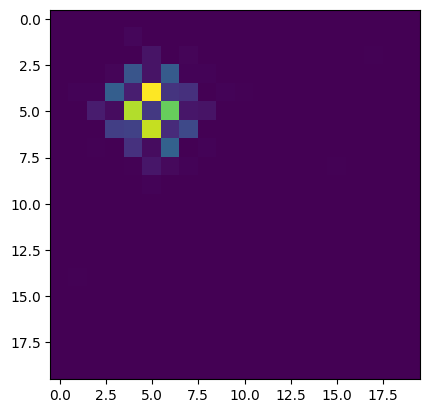

In [42]:
plt.imshow(bayer_image_example)
print(np.sum(bayer_image_example))

In [42]:
camera_calibration = camera_parameters

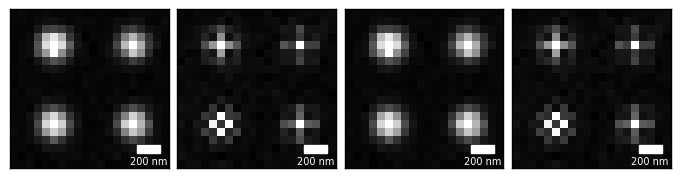

In [111]:
folder = '/home/jbeckwith/Documents/pCloud/Job Applications/URF/2025/ResearchProposal/Figures/Multicolour/'

fig, axs = plotter.two_column_plot(ncolumns=4, widthratio=[1,1,1,1])

axs[0] = plotter.image_plot(axs[0], data=normal_image, scalebarlabel='200 nm', scalebarsize=200, vmin=np.percentile(normal_image, 0.01), vmax=np.percentile(normal_image, 99), cbar='off')
axs[1] = plotter.image_plot(axs[1], data=bayer_image_example, scalebarlabel='200 nm', scalebarsize=200, vmin=np.percentile(bayer_image_example, 0.01), vmax=np.percentile(bayer_image_example, 99), cbar='off')

axs[2] = plotter.image_plot(axs[2], data=normal_image, scalebarlabel='200 nm', scalebarsize=200, vmin=np.percentile(normal_image, 0.01), vmax=np.percentile(normal_image, 99), cbar='off')
axs[3] = plotter.image_plot(axs[3], data=bayer_image_example, scalebarlabel='200 nm', scalebarsize=200, vmin=np.percentile(bayer_image_example, 0.01), vmax=np.percentile(bayer_image_example, 99), cbar='off')

plt.savefig(os.path.join(folder, 'example_bayer_concept.svg'), dpi=600, format='svg')
plt.show()

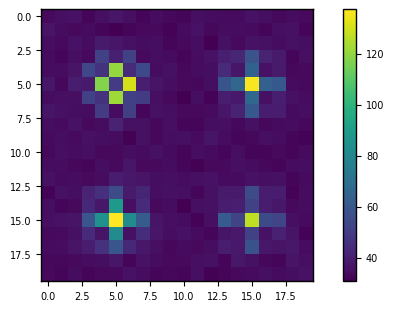

In [101]:
plt.imshow(bayer_image_example);plt.colorbar()

In [19]:
photoelectron_data = np.divide(
                np.divide(
                    np.subtract(bayer_image, camera_parameters["offset"]),
                    camera_parameters["gain"],
                ),
                camera_parameters["rqe"],
            )

In [20]:
smoothed_data = np.divide(
                np.divide(
                    np.subtract(smoothed_image, camera_parameters["offset"]),
                    camera_parameters["gain"],
                ),
                camera_parameters["rqe"],
            )

In [21]:
masks_3d = np.dstack([masks['B'], masks['G'], masks['R']])

In [22]:
gaussoptfuncs.initial_guess(smoothed_data, photoelectron_data, masks_3d)

(5.720349051837597,
 5.8997497202892655,
 2.8553255128592325,
 2.7702753156403634,
 4.746245111092769,
 3.8649606915320898,
 3.916426774201083,
 221.484491939578,
 221.484491939578,
 221.484491939578)

In [23]:
%timeit gaussoptfuncs.initial_guess(smoothed_data, photoelectron_data, masks_3d)

2.01 µs ± 1.79 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [ ]:
fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])

axs[0] = plotter.image_plot(axs=axs[0], data=bayer_image_Cy5[0, :, :], scalebarsize=200, scalebarlabel='200 nm')
axs[1] = plotter.image_plot(axs=axs[1], data=bayer_image_fakecamera[0, :, :], scalebarsize=200, scalebarlabel='200 nm')

In [ ]:
n_photons = {}
s = 10000
n_photons["Alexa Fluor 647"] = np.full(s, 2000)
#n_photons["CF680"] = np.full(s, 5000)

dyes = np.zeros([2, len(wavelength)])

x0y0 = {}
max = pixel_size * image_size

dyes = list(n_photons.keys())
average_emission_wavelengths, dye_pixel_efficiency = S_F.get_pixel_fractions_dye_and_filters(dyes, filters, wavelength, pixel_QYs)

center = max / 2
scaling = 1000

image_size = pixel_size * np.array(camera_parameters["gain"].shape)
x0 = np.full(s, (image_size[0]) / 2) + np.random.normal(
    scale=2*pixel_size, size=s
)
y0 = np.full(s, (image_size[1]) / 2) + np.random.normal(
    scale=2*pixel_size, size=s
)

for dye in n_photons:
    x0y0[dye] = np.zeros([s, 2, 1])
    x0y0[dye][:, :, :] = np.array([[x0, y0]]).T

bayer_image_AF647, normal_image =  MSF.gen_camera_image_stack(camera_parameters, wavelength,
                            average_emission_wavelengths, dye_pixel_efficiency, 
                            n_photons, x0y0, background_photons=background_photons, NA=NA, pixel_size=pixel_size, 
                            return_normal_image=True,)

In [ ]:
photoelectron_data_Cy5 = np.divide(
                np.divide(
                    np.subtract(bayer_image_Cy5, camera_parameters["offset"]),
                    camera_parameters["gain"],
                ),
                camera_parameters["rqe"],
            )

photoelectron_data_AF647 = np.divide(
                np.divide(
                    np.subtract(bayer_image_AF647, camera_parameters["offset"]),
                    camera_parameters["gain"],
                ),
                camera_parameters["rqe"],
            )

In [ ]:
smoothing_value = np.arange(2, 16)
error_values = np.zeros(len(smoothing_value))
for j, s_v in enumerate(smoothing_value):
    print("Analysing smoothing value {} \n".format(s_v), end="\r",flush=True,)        
    erd_Cy5 = sCMOS.var_weighted_uniform_filter(
                        photoelectron_data_Cy5, camera_parameters["variance"], s_v
                    )
    erd_Cy5[erd_Cy5 < 0] = 0
    erd_Cy5 = erd_Cy5 + 1
    error_map_Cy5 = np.add(erd_Cy5, np.square(camera_parameters["readnoise"]))
    weights_map_Cy5 = np.power(error_map_Cy5, -2)

    erd_AF647 = sCMOS.var_weighted_uniform_filter(
                        photoelectron_data_AF647, camera_parameters["variance"], s_v
                    )
    erd_AF647[erd_AF647 < 0] = 0
    erd_AF647 = erd_AF647 + 1
    error_map_AF647 = np.add(erd_AF647, np.square(camera_parameters["readnoise"]))
    weights_map_AF647 = np.power(error_map_AF647, -2)

    masks_3d = np.dstack(
                [camera_parameters["masks"][x] for x in camera_parameters["masks"].keys()]
            )
    vals = np.zeros([1000, 2])
    for i in np.arange(1000):
        pd_fit_Cy5 = photoelectron_data_Cy5[i, :, :]
        wm_fit_Cy5 = weights_map_Cy5[i, :, :]
        x_ig, y_ig, A, b = I_AF.initial_guess(
            erd_Cy5[i, :, :]-1
        )
        initial_guess = np.concatenate(
                                [
                                    np.array([x_ig, y_ig, A, 1.5, b]),
                                    np.mean(dye_library, axis=0)
                                ]
                            )
        args = {
            "data": pd_fit_Cy5,
            "initial_guess": initial_guess,
            "masks": masks_3d,
            "weights": wm_fit_Cy5,
            "pixel_order": camera_parameters["pixel_order_indices"],
            "display": False,
            "Rmin": Rmin,
            "Gmin": Gmin,
            "Bmin": Bmin,
            "Rmax": Rmax,
            "Gmax": Gmax,
            "Bmax": Bmax,
            "maxb":b*2
        }
        import types
        fitter = types.SimpleNamespace()
        fitter.default_params = np.array(["xc", "yc", "A", "sigma", "b", "R", "G", "B"])
        fitter.fit_function = I_AF.WLS_fit_colour_MIN
        result = fitter.fit_function(**args)
        vals[i, 0] = np.abs(np.argmin(np.sum(np.sqrt(np.square(result.x[5:] - dye_library)), axis=1)) - 0)
        
        pd_fit_AF647 = photoelectron_data_AF647[i, :, :]
        wm_fit_AF647 = weights_map_AF647[i, :, :]
        x_ig, y_ig, A, b = I_AF.initial_guess(
            erd_AF647[i, :, :]-1
        )
        initial_guess = np.concatenate(
                                [
                                    np.array([x_ig, y_ig, A, 1.5, b]),
                                    np.mean(dye_library, axis=0)
                                ]
                            )
        args = {
            "data": pd_fit_AF647,
            "initial_guess": initial_guess,
            "masks": masks_3d,
            "weights": wm_fit_AF647,
            "pixel_order": camera_parameters["pixel_order_indices"],
            "display": False,
            "Rmin": Rmin,
            "Gmin": Gmin,
            "Bmin": Bmin,
            "Rmax": Rmax,
            "Gmax": Gmax,
            "Bmax": Bmax,
            "maxb":b*2
        }
        import types
        fitter = types.SimpleNamespace()
        fitter.default_params = np.array(["xc", "yc", "A", "sigma", "b", "R", "G", "B"])
        fitter.fit_function = I_AF.WLS_fit_colour_MIN
        result = fitter.fit_function(**args)
        vals[i, 1] = np.abs(np.argmin(np.sum(np.sqrt(np.square(result.x[5:] - dye_library)), axis=1)) - 1)

    print("Smoothing mean {}, smoothing std {} \n".format(np.nanmean(vals), np.nanstd(vals)), end="\r")
    error_values[j] = np.nanmean(vals)

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.scatter_plot(axs=axs, x=smoothing_value, y=error_values*100, xaxislabel='Smoothing radius', yaxislabel='% error')

folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250327/fig/multicolour_camera/smoothing/'
file = 'MIN_smoothingparam.svg'
plt.savefig(os.path.join(folder, file), dpi=600, format='svg')

In [ ]:
smoothing_value = np.arange(2, 16)
error_values = np.zeros(len(smoothing_value))
for j, s_v in enumerate(smoothing_value):
    print("Analysing smoothing value {} \n".format(s_v), end="\r",flush=True,)        
    erd_Cy5 = sCMOS.var_weighted_uniform_filter(
                        photoelectron_data_Cy5, camera_parameters["variance"], s_v
                    )
    erd_Cy5[erd_Cy5 < 0] = 0
    erd_Cy5 = erd_Cy5 + 1
    error_map_Cy5 = np.add(erd_Cy5, np.square(camera_parameters["readnoise"]))
    weights_map_Cy5 = np.power(error_map_Cy5, -2)

    erd_AF647 = sCMOS.var_weighted_uniform_filter(
                        photoelectron_data_AF647, camera_parameters["variance"], s_v
                    )
    erd_AF647[erd_AF647 < 0] = 0
    erd_AF647 = erd_AF647 + 1
    error_map_AF647 = np.add(erd_AF647, np.square(camera_parameters["readnoise"]))
    weights_map_AF647 = np.power(error_map_AF647, -2)

    masks_3d = np.dstack(
                [camera_parameters["masks"][x] for x in camera_parameters["masks"].keys()]
            )
    vals = np.zeros([1000, 2])
    for i in np.arange(1000):
        pd_fit_Cy5 = photoelectron_data_Cy5[i, :, :]
        wm_fit_Cy5 = weights_map_Cy5[i, :, :]
        x_ig, y_ig, A, b = I_AF.initial_guess(
            erd_Cy5[i, :, :]-1
        )
        initial_guess = np.concatenate(
                                [
                                    np.array([x_ig, y_ig, A, 1.5, b]),
                                    np.mean(dye_library, axis=0)
                                ]
                            )
        args = {
            "data": pd_fit_Cy5,
            "initial_guess": initial_guess,
            "masks": masks_3d,
            "weights": wm_fit_Cy5,
            "pixel_order": camera_parameters["pixel_order_indices"],
            "display": False,
            "Rmin": Rmin,
            "Gmin": Gmin,
            "Bmin": Bmin,
            "Rmax": Rmax,
            "Gmax": Gmax,
            "Bmax": Bmax,
            "maxb":b*2
        }
        import types
        fitter = types.SimpleNamespace()
        fitter.default_params = np.array(["xc", "yc", "A", "sigma", "b", "R", "G", "B"])
        fitter.fit_function = I_AF.WLS_fit_colour
        result = fitter.fit_function(**args)
        vals[i, 0] = np.abs(np.argmin(np.sum(np.sqrt(np.square(result.x[5:] - dye_library)), axis=1)) - 0)
        
        pd_fit_AF647 = photoelectron_data_AF647[i, :, :]
        wm_fit_AF647 = weights_map_AF647[i, :, :]
        x_ig, y_ig, A, b = I_AF.initial_guess(
            erd_AF647[i, :, :]-1
        )
        initial_guess = np.concatenate(
                                [
                                    np.array([x_ig, y_ig, A, 1.5, b]),
                                    np.mean(dye_library, axis=0)
                                ]
                            )
        args = {
            "data": pd_fit_AF647,
            "initial_guess": initial_guess,
            "masks": masks_3d,
            "weights": wm_fit_AF647,
            "pixel_order": camera_parameters["pixel_order_indices"],
            "display": False,
            "Rmin": Rmin,
            "Gmin": Gmin,
            "Bmin": Bmin,
            "Rmax": Rmax,
            "Gmax": Gmax,
            "Bmax": Bmax,
            "maxb":b*2
        }
        import types
        fitter = types.SimpleNamespace()
        fitter.default_params = np.array(["xc", "yc", "A", "sigma", "b", "R", "G", "B"])
        fitter.fit_function = I_AF.WLS_fit_colour
        result = fitter.fit_function(**args)
        vals[i, 1] = np.abs(np.argmin(np.sum(np.sqrt(np.square(result.x[5:] - dye_library)), axis=1)) - 1)

    print("Smoothing mean {}, smoothing std {} \n".format(np.nanmean(vals), np.nanstd(vals)), end="\r")
    error_values[j] = np.nanmean(vals)

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.scatter_plot(axs=axs, x=smoothing_value, y=error_values*100, xaxislabel='Smoothing radius', yaxislabel='% error')

folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250327/fig/multicolour_camera/smoothing/'
file = 'LM_smoothingparam.svg'
plt.savefig(os.path.join(folder, file), dpi=600, format='svg')

In [ ]:
dye_n = np.argmin(np.sum(np.abs(dye_fit_expectation - dye_library), axis=1))
dye_n

In [ ]:
def plot_image_fft(input_image, n_labels=7, d=1):
    
    '''
    Plot an image alongside its frequency-domain representation.
    
    
    Parameters
    ----------
    img_path: (str) the path to an image
    n_labels: (int) the number of labels to space out along each axis, default=7
                      best if an odd number
    
    d: (int) sample spacing (inverse of the sampling rate). default=1
                      if the image has meaningful units, this can be altered to match
    
    '''
    
    # trying to get the units of the FFT plot
    #  "The returned float array `f` contains the frequency bin centers in cycles
    #   per unit of the sample spacing (with zero at the start).  For instance, if
    #  the sample spacing is in seconds, then the frequency unit is cycles/second."
    freqx = np.fft.fftfreq(input_image.shape[1], d=1)
    freqy = np.fft.fftfreq(input_image.shape[0], d=1)
    x_step = int(input_image.shape[1]/n_labels)
    xtick_pos = np.arange(0,input_image.shape[1])[::x_step]
    xtick_labels = np.round(freqx[::x_step],2)
    y_step = int(input_image.shape[0]/n_labels)
    ytick_pos = np.arange(0,input_image.shape[0])[::y_step]
    ytick_labels = np.round(freqy[::y_step],2)

    # convert to frequency domain
    img_freq = np.fft.fft2(input_image)

    # calculate amplitude spectrum
    img_amp = np.fft.fftshift(np.abs(img_freq))

    # for display, take the logarithm
    img_amp_disp = np.log10(img_amp)

    # rescale to [0.0, 1.0] for display

    fig,ax = plt.subplots(1,2, figsize=(10,6))
    ax[0].imshow(input_image)
    ax[1].imshow(img_amp_disp)
    ax[1].set_xticks(xtick_pos, xtick_labels)
    ax[1].set_yticks(ytick_pos, ytick_labels)
    plt.show()
    plt.close()

In [ ]:
photon_levels = np.array([500, 1000, 2000])
background_level = 10
n_molecules = 100

In [ ]:
data = np.zeros([len(photon_levels), n_molecules])
for i, photon in enumerate(photon_levels):
    data[i, :] = np.random.poisson(lam=photon+background_level, size=n_molecules)

In [ ]:
data[0, :]

In [ ]:
fig, axs = plotter.one_column_plot(height=1.5)

axs = plotter.histogram_plot(axs=axs, data=data[0, :], bins=np.histogram_bin_edges(data[0, :], bins='sturges'), alpha=1, xaxislabel='estimated photons per molecule', density=False)
#axs = plotter.histogram_plot(axs=axs, data=data[1, :], bins=np.histogram_bin_edges(data[1, :], bins='sturges'), alpha=1, xaxislabel='estimated photons per molecule', density=False)
#axs = plotter.histogram_plot(axs=axs, data=data[2, :], bins=np.histogram_bin_edges(data[2, :], bins='sturges'), alpha=1, xaxislabel='estimated photons per molecule', density=False)

save_folder = r'C:\Users\jsb92\Cambridge University Dropbox\Joseph Beckwith\Chemistry\Lee'
    #save_folder = '/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250130/fig/multicolour_camera/dye_unmixing'
    
axs.set_xlim([400, 700])
save_file = 'example_500photons_hist.svg'
plt.savefig(os.path.join(save_folder, save_file), dpi=600, format='svg')

In [ ]:
plt.imshow(bayer_image);plt.colorbar()

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(axs=axs, data=bayer_image, scalebarsize=1000, scalebarlabel=r'1 $\mu$m', cbarlabel='intensity')

save_folder = r'C:\Users\jsb92\Cambridge University Dropbox\Joseph Beckwith\Chemistry\Lee'
#save_folder = '/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250130/fig/multicolour_camera/dye_unmixing'

save_file = 'example_500photons.svg'
plt.savefig(os.path.join(save_folder, save_file), dpi=600, format='svg')

In [ ]:
from SpotDetectionFunctions import SpotDetection_Functions
SD_F = SpotDetection_Functions()

In [ ]:
puncta = SD_F.detect_puncta_in_image(bayer_image, mf_factor=3, local_factor=3)

In [ ]:
fig, axs = plotter.two_column_plot(ncolumns=3, widthratio=[1,1,1])

axs[0] = plotter.image_plot(axs=axs[0], data=bayer_image, scalebarsize=300, scalebarlabel='300 nm', cbarlabel='image intensity')
axs[1] = plotter.image_plot(axs=axs[1], data=filtered_image, scalebarsize=300, scalebarlabel='300 nm', cbar='off')
axs[2] = plotter.image_scatter_plot(axs=axs[2], data=bayer_image, xdata=puncta[:,0], ydata=puncta[:,1], s=1000, lws=1, scalebarsize=300, scalebarlabel='300 nm', cbar='off')

save_folder = '/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250130/fig/multicolour_camera/spot_detection/'
save_file = 'example_spotdetection_multicolour.svg'
plt.savefig(os.path.join(save_folder, save_file), dpi=600, format='svg')

In [ ]:
image_for_detection = image_for_detection = np.divide(bayer_image, 1)
psf_fun = SD_F.gauss2d
sigma = np.divide(PSF.sigma_PSF(0.6, 1.49), 0.069)
mf_factor = 3
mf_range = int(np.ceil(mf_factor * sigma))
w = SD_F.get_mf(psf_fun, sigma, mf_range)
guard_interval = int(np.ceil(mf_factor * sigma))
reference_interval = int(np.ceil(mf_factor * sigma))
local_max_range = int(np.ceil(3 * sigma))
filtered_image = SD_F.filter_image(image_for_detection, w)
square_annulus = SD_F.get_square_annulus(guard_interval, reference_interval)

In [ ]:
plt.imshow(filtered_image);plt.colorbar()

In [ ]:
b_estimate = SD_F.cacfar_background_mean_estimate(filtered_image, square_annulus)
b_std_estimate = SD_F.cacfar_background_std_estimate(filtered_image, b_estimate, square_annulus)

In [ ]:
filtered_image

In [ ]:
mask = SD_F.cacfar(filtered_image, 10**-4, local_max_range, kernel=square_annulus)

In [ ]:
plt.imshow(mask)

In [ ]:
dye_names = x0y0.keys()

gain = camera_calibration["gain"]
offset = camera_calibration["offset"]
variance = camera_calibration["variance"]
relative_QE = camera_calibration["rqe"]

average_emission_wavelengths = np.trapz(
    y=wavelength * (dyes.T / np.trapz(x=wavelength, y=dyes)).T, x=wavelength
)
sigma_PSFs = PSF.sigma_PSF(average_emission_wavelengths, NA)

dye_pixel_efficiency = np.dot(dyes, absolute_QYs.T)

h = gain.shape[0]
w = gain.shape[1]

x = np.linspace(0, (pixel_size * h) - pixel_size, h)
y = np.linspace(0, (pixel_size * w) - pixel_size, w)

In [ ]:
photon_spatial_pdf = PSF.gen_spatial_PSF(
    x,
    y,
    sigma_PSFs[0],
    max / 2,
    max / 2,
    int(1000),
    relative_QE,
)

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=photon_spatial_pdf,
    scalebarlabel="300 nm",
    cbarlabel="photons",
    pixelsize=140,
    scalebarsize=300,
    labelcolor="white",
)

plt.tight_layout()
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera/dyes"
plt.savefig(os.path.join(folder, "PSF_ATTO550_inputPSF.svg"), format="svg", dpi=600)

In [ ]:
n_photons_hitting_detector = PSF.gen_photons_hitting_detector(
    photon_spatial_pdf, background_photons
)

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=n_photons_hitting_detector,
    scalebarlabel="300 nm",
    cbarlabel="photons",
    pixelsize=140,
    scalebarsize=300,
    labelcolor="white",
)

plt.tight_layout()
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera/dyes"
plt.savefig(
    os.path.join(folder, "PSF_ATTO550_photonshittingdetector.svg"),
    format="svg",
    dpi=600,
)

In [ ]:
n_photoelectrons = PSF.gen_photoelectrons(n_photons_hitting_detector, 0.95)

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=n_photoelectrons,
    scalebarlabel="300 nm",
    cbarlabel="photoelectrons",
    pixelsize=140,
    scalebarsize=300,
    labelcolor="white",
)

plt.tight_layout()
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera/dyes"
plt.savefig(
    os.path.join(folder, "PSF_ATTO550_nphotoelectrons.svg"), format="svg", dpi=600
)

In [ ]:
image_matrix = PSF.photoelectrons_to_image(n_photoelectrons, gain, offset, variance)

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=image_matrix,
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=140,
    scalebarsize=300,
    labelcolor="white",
)

plt.tight_layout()
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera/dyes"
plt.savefig(os.path.join(folder, "PSF_ATTO550_intensity.svg"), format="svg", dpi=600)

In [ ]:
photoelectron_data = np.divide(
    np.divide(
        np.subtract(bayer_image, camera_calibration["offset"]),
        camera_calibration["gain"],
    ),
    camera_calibration["rqe"],
)

In [ ]:
from skimage.filters import gaussian

masks = MSF.MF.get_masks(MSF.mosaic_unit, image_size, image_size)
masks_3d = np.dstack([masks["maskR"], masks["maskG"], masks["maskB"]])

In [ ]:
xc_ig, yc_ig = np.unravel_index(
    np.argmax(gaussian(photoelectron_data)),
    photoelectron_data.shape,
)
erd = sCMOS.var_weighted_uniform_filter(
    photoelectron_data, camera_calibration["variance"], 4
)
erd[erd < 0] = 0
erd = erd + 1
error_map = np.add(erd, np.square(camera_calibration["readnoise"]))
weights_map = np.power(error_map, -2)

A = np.sum((photoelectron_data))
sigma = 3
b = 0
initial_guess = np.array([xc_ig, yc_ig, A, sigma, b, 1, 1, 1])
result = AF.WLS_fit(
    photoelectron_data,
    initial_guess,
    masks=masks_3d,
    weights=weights_map,
    display=False,
)

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=bayer_image,
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=140,
    scalebarsize=300,
    labelcolor="white",
)

plt.tight_layout()
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Cambridge_Enterprise/20241204/fig/multicolour_camera/dyes"
plt.savefig(
    os.path.join(folder, "PSF_ATTO488_ATTO550_ATTO647N_ATTO740_perfectcamera.svg"),
    format="svg",
    dpi=600,
)

In [ ]:
fit[-3:]

In [ ]:
optimised_PSF = AF.WLS_model(data=photoelectron_data, masks=masks_3d, params=fit)

In [ ]:
fig, axs = plotter.two_column_plot(widthratio=[1, 1], ncolumns=2)

axs[0] = plotter.image_plot(
    axs=axs[0],
    data=photoelectron_data,
    scalebarlabel="300 nm",
    cbarlabel="photoelectrons",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="white",
)
axs[1] = plotter.image_plot(
    axs=axs[1],
    data=weights_map,
    scalebarlabel="300 nm",
    cbarlabel="fit weighting",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="white",
)

plt.tight_layout()
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera/dyes"
plt.savefig(
    os.path.join(folder, "PSF_ATTO550_photoelectronmap.svg"), format="svg", dpi=600
)

In [ ]:
fig, axs = plotter.two_column_plot(
    widthratio=[1, 1], heightratio=[1, 1], ncolumns=2, nrows=2
)

axs[0, 0] = plotter.image_plot(
    axs=axs[0, 0],
    data=ground_truth.values[:, :, 0],
    cmap="Blues",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)
axs[1, 0] = plotter.image_plot(
    axs=axs[1, 0],
    data=ground_truth.values[:, :, 1],
    cmap="Greens",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)
axs[0, 1] = plotter.image_plot(
    axs=axs[0, 1],
    data=ground_truth.values[:, :, 2],
    cmap="Reds",
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
    labelcolor="k",
)
axs[1, 1] = plotter.image_plot(
    axs=axs[1, 1],
    data=bayer_image[:, :],
    scalebarlabel="300 nm",
    cbarlabel="intensity",
    pixelsize=69,
    scalebarsize=300,
)

plt.tight_layout()
# folder = '/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20241017/fig/Colour'
# plt.savefig(os.path.join(folder, 'PSF_ATTO390_ATTO550_ATTO655_ATTO740_4000photons.svg'), format='svg', dpi=600)

In [ ]:
n_photon_lspace = np.linspace(500, 20000, 1000)
n_bootstrap = 1000

estimator_error_mean = np.zeros([3, len(n_photon_lspace)])
estimator_error_std = np.zeros([3, len(n_photon_lspace)])

start = time.time()
for i, photon_number in enumerate(n_photon_lspace):
    n_photons = {}
    n_photons["ATTO390"] = photon_number
    n_photons["ATTO550"] = photon_number
    n_photons["ATTO655"] = photon_number
    n_photons["ATTO740"] = photon_number
    estimator_error = np.zeros([3, n_bootstrap])
    for j in np.arange(n_bootstrap):
        ground_truth, bayer_image = MSF.gen_camera_images(
            camera_calibration,
            wavelength,
            absolute_QYs,
            dyes,
            n_photons,
            x0y0,
            background_photons=background_photons,
            NA=NA,
            pixel_size=pixel_size,
        )

        Bilinear = colour.cctf_encoding(demosaicing_CFA_Bayer_bilinear(bayer_image))
        Bilinear = Bilinear / (
            np.median(np.median(Bilinear, axis=1), axis=0) / np.median(bayer_image)
        )
        Malvar = colour.cctf_encoding(demosaicing_CFA_Bayer_Malvar2004(bayer_image))
        Malvar = Malvar / (
            np.median(np.median(Malvar, axis=1), axis=0) / np.median(bayer_image)
        )
        Menon = colour.cctf_encoding(demosaicing_CFA_Bayer_Menon2007(bayer_image))
        Menon = Menon / (
            np.max(np.median(Menon, axis=1), axis=0) / np.median(bayer_image)
        )

        # do bilinear errors
        Rerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 2] - Bilinear[:, :, 0]))
        )
        Gerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 1] - Bilinear[:, :, 1]))
        )
        Berror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 0] - Bilinear[:, :, 2]))
        )
        estimator_error[0, j] = np.mean([Rerror, Gerror, Berror])

        # do Malvar errors
        Rerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 2] - Malvar[:, :, 0]))
        )
        Gerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 1] - Malvar[:, :, 1]))
        )
        Berror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 0] - Malvar[:, :, 2]))
        )
        estimator_error[1, j] = np.mean([Rerror, Gerror, Berror])

        # do Menon errors
        Rerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 2] - Menon[:, :, 0]))
        )
        Gerror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 1] - Menon[:, :, 1]))
        )
        Berror = np.mean(
            np.sqrt(np.square(ground_truth.values[:, :, 0] - Menon[:, :, 2]))
        )
        estimator_error[2, j] = np.mean([Rerror, Gerror, Berror])

    estimator_error_mean[:, i] = np.mean(estimator_error, axis=1)
    estimator_error_std[:, i] = np.std(estimator_error, axis=1)

    print(
        "Analysed photon flux {}/{}    Time elapsed: {:.3f} s".format(
            i + 1, len(n_photon_lspace), time.time() - start
        ),
        end="\r",
        flush=True,
    )